# PHASE 2
# FULL FINE-TUNING FOR BraTS2021
# SwinUNETR Fine-Tuning and Segmentation Mask Generation

This notebook fully fine-tunes a pretrained SwinUNETR model for brain tumor segmentation on BraTS2021, using the best preprocessing configuration from Phase 1. The model is evaluated by Dice (DSC) and Hausdorff Distance (HD95) per subregion (TC, WT, ET), and the predicted masks are saved for feature extraction.

Key choices:
- **Preprocessing** - Tumor-Focused Sampling (Phase 1, Experiment 2: `RandCropByPosNegLabeld`, pos=3, neg=1).
- **Validation** - Fold 1 held out throughout (~250 patients).
- **Output** - predicted segmentation masks for Phase 3.

## Overview

This notebook proceeds in three stages:

1. **Pretrained model**: a SwinUNETR pretrained on BraTS (MONAI `model_fold1`) is loaded as the starting point (no training here).
2. **Fine-tuning**: the network is fine-tuned on BraTS2021 (all folds except `val_fold`) with tumor-focused sampling, Dice loss and AdamW; the best checkpoint by mean DSC is saved.
3. **Evaluation & mask generation**: the best fine-tuned model is evaluated (DSC, HD95 per subregion) and used to generate predicted masks for the whole validation cohort.

All configurable parameters (paths, `val_fold`, `roi_size`, `batch_size`, `max_epochs`, `val_every`, `lr`, `overlap`) are **centralised in the configuration cell** at the top. The values used here are one instance of the design.

Input channel order is **[FLAIR, T1ce, T1, T2]**. Output channel order is **[TC, WT, ET]**.

## 1. Environment setup and library versions

Import required libraries and display their versions along with CUDA availability and GPU information for reproducibility.

In [12]:
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import nibabel
import einops
import tqdm
import numpy
import os
import json

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import monai
from monai.data import Dataset, DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.metrics import HausdorffDistanceMetric
from monai.utils.enums import MetricReduction
from monai.inferers import sliding_window_inference
from monai.transforms import (
    SpatialPadd,
    LoadImaged,
    ConvertToMultiChannelBasedOnBratsClassesd,
    RandCropByPosNegLabeld,
    RandFlipd,
    NormalizeIntensityd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
)

print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)
print("nibabel:", nibabel.__version__)
print("einops:", einops.__version__)
print("tqdm:", tqdm.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)

PyTorch: 2.12.0.dev20260408+cu128
MONAI: 1.5.2
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM (GB): 17.102864384
nibabel: 5.4.2
einops: 0.4.1
tqdm: 4.59.0
numpy: 1.26.4
matplotlib: 3.10.9


## 2. Set up file paths and output folders

Define paths for the data directory, the JSON file containing fold splits, the pretrained model, the output directory and the masks directory for inference.
All output folders are created if they do not already exist.

In [ ]:
# Central configuration
# To re-run the experiment under different settings, edit only this cell.

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

# Paths
# NOTE: data_dir must be the folder containing TrainingData/, because the JSON paths are prefixed 
# with "TrainingData/..." (joined onto data_dir in build_file_list).
# Input channel order throughout is [FLAIR, T1ce, T1, T2]; output channels are [TC, WT, ET].
data_dir = os.path.join(project_root, "data", "BraTS21", "BraTS2021_Training_Data")
json_path = os.path.join(project_root, "jsons", "brats21_folds.json")
pretrained_path = os.path.join(project_root, "pretrained_models", "model_fold1", "model.pt")
output_dir = os.path.join(project_root, "outputs", "outputs_full_finetuning")
masks_dir = os.path.join(output_dir, "predicted_masks")
finetuned_path  = os.path.join(output_dir, "fine_tuning_best_model.pt") 

os.makedirs(output_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

# Data split
val_fold = 1   # fold held out for validation, all other folds are used for training

# Training settings
roi_size = (128, 128, 128)   # sliding-window/crop size
batch_size = 1
max_epochs = 100
val_every = 10  # run validation every `val_every` epochs (plus an epoch-0 baseline)
lr = 1e-4
overlap = 0.5   # sliding-window inference overlap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Project root: {project_root}")
print(f"Output dir: {output_dir}")
print(f"Data dir exists: {os.path.exists(data_dir)}")
print(f"JSON folds exist: {os.path.exists(json_path)}")
print(f"Pretrained model exists: {os.path.exists(pretrained_path)}")
print(f"Finetuned model path: {finetuned_path}")

## 3. Load the fold splits and separate validation from training

Patients whose fold equals val_fold (set in the configuration cell) are held out as the validation set, all remaining folds form the training set. Exact patient counts follow from the fold definitions in the splits JSON.

In [5]:
# Load the JSON file containing the 5‑fold split information.
with open(json_path, "r") as f:
    splits = json.load(f)

# Separate validation from the training
all_training = splits["training"]
train_cases = [case for case in all_training if case["fold"] != val_fold]
val_cases   = [case for case in all_training if case["fold"] == val_fold]

print(f"Total: {len(all_training)} | "
      f"Train (folds != {val_fold}): {len(train_cases)} | "
      f"Val (fold {val_fold}): {len(val_cases)}")

Total: 1251 | Train (folds != 1): 1001 | Val (fold 1): 250


## 4. Create file lists for training and validation

Build a list of dictionaries containing full paths to the four MRI modalities (FLAIR, T1ce, T1, T2) and the segmentation mask for each patient. Verify that files exist before proceeding.

In [ ]:
def build_file_list(cohort, data_dir):
    data_list = []
    for case in cohort:
        data_list.append({
            "image": [
                os.path.join(data_dir, case["image"][0]), # channel 0 = FLAIR
                os.path.join(data_dir, case["image"][1]), # channel 1 = T1ce
                os.path.join(data_dir, case["image"][2]), # channel 2 = T1
                os.path.join(data_dir, case["image"][3]), # channel 3 = T2
            ],
            "label": os.path.join(data_dir, case["label"])
        })
    return data_list

train_files = build_file_list(train_cases, data_dir)
val_files = build_file_list(val_cases, data_dir)

print(f"Training patients: {len(train_files)}")
print(f"Validation patients: {len(val_files)}")
print(f"\nFile exists check:")
print(f"Train image exists: {os.path.exists(train_files[0]['image'][0])}")
print(f"Train label exists: {os.path.exists(train_files[0]['label'])}")
print(f"Val image exists: {os.path.exists(val_files[0]['image'][0])}")
print(f"Val label exists: {os.path.exists(val_files[0]['label'])}")

missing_train = [f for f in train_files if not all(os.path.exists(p) for p in f["image"]) or not os.path.exists(f["label"])]
missing_val = [f for f in val_files   if not all(os.path.exists(p) for p in f["image"]) or not os.path.exists(f["label"])]

print(f"Missing train files: {len(missing_train)}")
print(f"Missing val files: {len(missing_val)}")

if missing_train:
    print(f"First missing train case: {missing_train[0]['label']}")
if missing_val:
    print(f"First missing val case: {missing_val[0]['label']}")

## 5. Inspect a sample image and its label

Load one patient’s FLAIR image and segmentation mask, print their shapes and display a central slice to confirm correct loading and label values.

Sample patient: BraTS2021_01146
Image exists: True
Label exists: True
Image shape: (240, 240, 155), Label shape: (240, 240, 155)
Unique label values: [0. 1. 2. 4.]


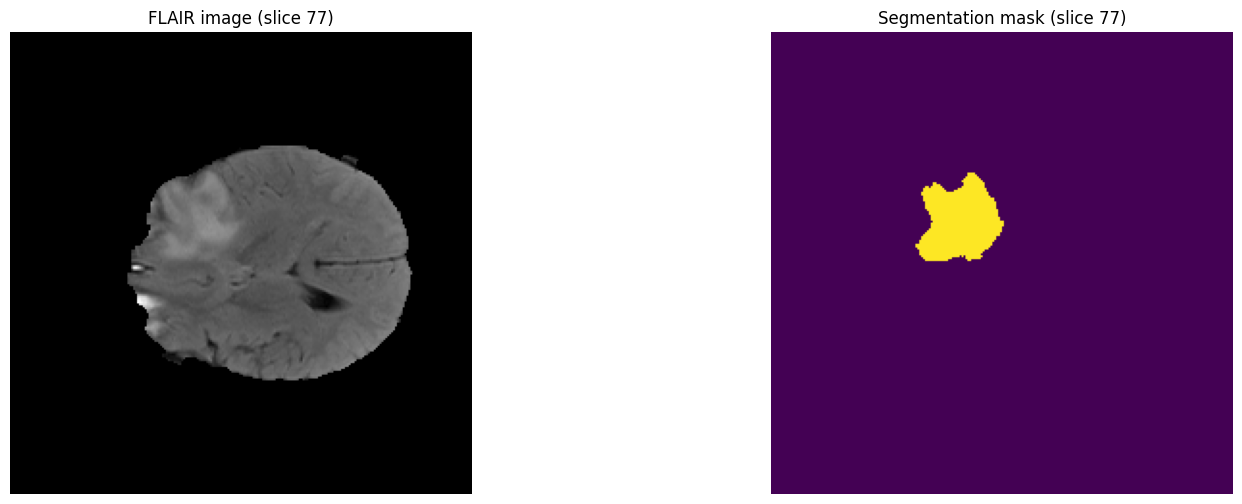

In [7]:
# Inspect one sample (FLAIR + segmentation) chosen generically from the file lists.

sample = train_files[0]
img_add = sample["image"][0]   # channel 0 = FLAIR
label_add = sample["label"]
pid = os.path.basename(os.path.dirname(label_add))

print(f"Sample patient: {pid}")
print(f"Image exists: {os.path.exists(img_add)}")
print(f"Label exists: {os.path.exists(label_add)}")

img = nibabel.load(img_add).get_fdata()
label = nibabel.load(label_add).get_fdata()
print(f"Image shape: {img.shape}, Label shape: {label.shape}")
print(f"Unique label values: {numpy.unique(label)}")

mid = img.shape[2] // 2   # generic mid-axial slice
plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)
plt.title(f"FLAIR image (slice {mid})")
plt.imshow(img[:, :, mid], cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title(f"Segmentation mask (slice {mid})")
plt.imshow(label[:, :, mid])
plt.axis("off")
plt.savefig(os.path.join(output_dir, "sample_image_label.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Validation transforms

Compose a fixed MONAI transform pipeline for validation: load the four modality images, ensure channel-first ordering, convert the segmentation label to three binary channels (TC, WT, ET) using `ConvertToMultiChannelBasedOnBratsClassesd`, apply channel-wise intensity normalization on non-zero voxels and convert to PyTorch tensors. No augmentation is applied.

In [ ]:
# Validation transforms
val_transforms = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),    # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            EnsureTyped(keys=["image", "label"]),
        ]
    )

print("Validation transforms were defined.")

## 7. Training transforms - Experiment 2 (Tumor-Focused Sampling)

Apply the best preprocessing configuration identified in the preprocessing experiments: `RandCropByPosNegLabeld` with pos=3, neg=1 to focus 75% of crops on tumor regions, followed by spatial padding, random flips on all axes, channel-wise intensity normalization and random intensity scaling and shifting for augmentation.

In [ ]:
train_transforms = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),    # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            RandCropByPosNegLabeld(
                keys=["image", "label"],
                label_key="label",
                spatial_size=roi_size,
                pos=3,
                neg=1,
                num_samples=1,
                image_key="image",
                image_threshold=0,
            ),
            SpatialPadd(keys=["image", "label"], spatial_size=roi_size),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
            EnsureTyped(keys=["image", "label"], data_type="tensor", dtype=torch.float32),
        ]
    )

print("Training transforms were defined (Experiment 2 - Tumor-Focused Sampling).")

## 8. Function to build DataLoaders

Define a helper function that creates MONAI `Dataset` and `DataLoader` objects for training and validation. The training loader is shuffled, the validation loader is not. `pin_memory=True` is enabled to speed up CPU to GPU transfers.

In [ ]:
def get_dataloaders(train_transforms, train_files, val_files):
    train_ds = Dataset(data=train_files, transform=train_transforms)
    val_ds = Dataset(data=val_files, transform=val_transforms)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    
    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    return train_loader, val_loader

print("Data loader function was defined.")

## 9. Build and load the SwinUNETR model

Define a helper that builds the SwinUNETR architecture and loads a checkpoint. The same function is reused for both the pretrained starting point and the fine-tuned checkpoint. It accepts the three common checkpoint layouts (`state_dict`, `model` key or `raw state dict`) and loading is verified once on the pretrained checkpoint.

In [ ]:
# SwinUNETR builder and loader
# The architecture is defined for both the pretrained checkpoint and the fine-tuned checkpoint.

def build_swin_unetr(roi_size, device):
    """Construct the SwinUNETR used throughout this notebook."""
    model = SwinUNETR(
        img_size=roi_size,   # spatial size of the sliding-window ROI
        in_channels=4,   # FLAIR, T1ce, T1, T2
        out_channels=3,   # TC, WT, ET
        feature_size=48,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        dropout_path_rate=0.0,
        use_checkpoint=True,
    )
    return model.to(device)

def load_model(path, device, roi_size=roi_size):
    """Build the network and load a checkpoint (pretrained or fine-tuned).
    Handles the three checkpoint layouts encountered: a raw state_dict or a dict wrapped under 'state_dict' or 'model'.
    """
    model = build_swin_unetr(roi_size, device)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    if "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    elif "model" in ckpt:
        model.load_state_dict(ckpt["model"])
    else:
        model.load_state_dict(ckpt)
    return model

# Quick load test of the pretrained checkpoint (free memory immediately after).
_test = load_model(pretrained_path, device)
del _test
if device.type == "cuda":
    torch.cuda.empty_cache()
print("Unified load_model() is OK - pretrained checkpoint loads correctly.")


## 10. Run full fine-tuning

Fine-tune the pretrained SwinUNETR on all ~1000 training patients for up to `max_epochs` epochs, validating every `val_every` epochs plus epoch 0 as a pretrained baseline before any fine-tuning. Tracks per-subregion DSC and HD95 (TC, WT, ET), handles NaN HD95 values from empty ET masks via `nan_to_num` and saves the best checkpoint based on mean DSC across all three subregions.

In [ ]:
best_mean_dice = 0
best_metrics = {}

model = load_model(pretrained_path, device)          # unified loader (pretrained start point)
train_loader, val_loader = get_dataloaders(train_transforms, train_files, val_files)

loss_fn = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
hd95_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

train_losses = []
val_history  = {
    "val_dice_mean": [], "val_dice_tc": [], "val_dice_wt": [], "val_dice_et": [],
    "val_hd95_mean": [], "val_hd95_tc": [], "val_hd95_wt": [], "val_hd95_et": [],
}

for epoch in range(0, max_epochs + 1):
    # Training
    if epoch > 0:
        model.train()
        epoch_loss = 0

        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step()
        print(f"Epoch {epoch}/{max_epochs} | Train Loss: {avg_loss:.4f}")

    # Validation (epoch-0 baseline + every val_every epochs)
    if epoch == 0 or epoch % val_every == 0:
        model.eval()
        with torch.no_grad():
            for val_batch in val_loader:
                val_images = val_batch["image"].to(device)
                val_labels = val_batch["label"].to(device)
                val_outputs = sliding_window_inference(val_images, roi_size, sw_batch_size=1, predictor=model, overlap=overlap)
                val_outputs = (torch.sigmoid(val_outputs) > 0.5).float().   # sigmoid>0.5 per channel -> binary TC/WT/ET masks
                dice_metric(y_pred=val_outputs, y=val_labels)
                hd95_metric(y_pred=val_outputs, y=val_labels)

            dice_scores = dice_metric.aggregate()
            dice_metric.reset()

            hd95_scores, _ = hd95_metric.aggregate()
            hd95_metric.reset()
            hd95_scores = torch.nan_to_num(hd95_scores, nan=0.0, posinf=0.0)

            # channel order: 0 = TC, 1 = WT, 2 = ET
            tc_dice, wt_dice, et_dice = dice_scores[0].item(), dice_scores[1].item(), dice_scores[2].item()
            mean_dice = (tc_dice + wt_dice + et_dice) / 3
            tc_hd95, wt_hd95, et_hd95 = hd95_scores[0].item(), hd95_scores[1].item(), hd95_scores[2].item()
            mean_hd95 = (tc_hd95 + wt_hd95 + et_hd95) / 3

            val_history["val_dice_mean"].append(mean_dice)
            val_history["val_dice_tc"].append(tc_dice)
            val_history["val_dice_wt"].append(wt_dice)
            val_history["val_dice_et"].append(et_dice)
            val_history["val_hd95_mean"].append(mean_hd95)
            val_history["val_hd95_tc"].append(tc_hd95)
            val_history["val_hd95_wt"].append(wt_hd95)
            val_history["val_hd95_et"].append(et_hd95)

            print(f"  Val DSC  -> TC: {tc_dice:.4f} | WT: {wt_dice:.4f} | ET: {et_dice:.4f} | Mean: {mean_dice:.4f}")
            print(f"  Val HD95 -> TC: {tc_hd95:.2f} | WT: {wt_hd95:.2f} | ET: {et_hd95:.2f} | Mean: {mean_hd95:.2f}")

            if mean_dice > best_mean_dice:
                best_mean_dice = mean_dice
                torch.save(model.state_dict(), os.path.join(output_dir, "fine_tuning_best_model.pt"))
                best_metrics = {
                    "best_epoch": epoch,
                    "dice_mean":  mean_dice,
                    "dice_tc":    tc_dice,
                    "dice_wt":    wt_dice,
                    "dice_et":    et_dice,
                    "hd95_mean":  mean_hd95,
                    "hd95_tc":    tc_hd95,
                    "hd95_wt":    wt_hd95,
                    "hd95_et":    et_hd95,
                }
                print(f"\nNew best model saved at epoch {epoch} (Mean DSC: {mean_dice:.4f})\n")

print(f"\nTraining completed. Best Mean DSC: {best_mean_dice:.4f}")

## 11. Save training results to disk

Serialise training losses, full validation history and best checkpoint metrics to a single JSON file.

In [16]:
def build_val_epochs(n_val, val_every, max_epochs):
    """Reconstruct the epochs at which validation was recorded.

    Works whether or not an epoch-0 baseline validation was included, by matching the actual number 
    of validation points (n_val).
    """
    with_baseline = [0] + list(range(val_every, max_epochs + 1, val_every))
    without_baseline = list(range(val_every, max_epochs + 1, val_every))
    if n_val == len(with_baseline):
        return with_baseline
    if n_val == len(without_baseline):
        return without_baseline
    return with_baseline[:n_val]   # fallback: first n_val scheduled points

In [ ]:
results_ft = {
    "best_metrics": {k: float(v) for k, v in best_metrics.items()},
    "train_losses": [float(v) for v in train_losses],
    "val_history": {k: [float(v) for v in vals] for k, vals in val_history.items()},
}

results_path = os.path.join(output_dir, "results_fine_tuning.json")
with open(results_path, "w") as f:
    json.dump(results_ft, f, indent=2)
print(f"Results saved - {results_path}")

pd.DataFrame([best_metrics]).to_csv(os.path.join(output_dir, "best_metrics.csv"), index=False)

# Build the validation-epoch axis from the actual number of recorded validations.
val_epochs = build_val_epochs(len(val_history["val_dice_mean"]), val_every, max_epochs)
val_df = pd.DataFrame(val_history)
val_df.insert(0, "epoch", val_epochs)
val_df.to_csv(os.path.join(output_dir, "val_history.csv"), index=False)

print("CSVs saved - best_metrics.csv, val_history.csv")

## 12. Load saved results (optional - only when reopening the notebook)

In [ ]:
# OPTIONAL - run this only when reopening the notebook to restore results from disk without re-training. 
# If you have just run the training and save cells above, the in-memory variables are already correct 
# and this cell can be skipped.

with open(os.path.join(output_dir, "results_fine_tuning.json")) as f:
    results_ft = json.load(f)

best_metrics = results_ft["best_metrics"]
train_losses = results_ft["train_losses"]
val_history = results_ft["val_history"]

print("Results loaded successfully.")
print(f"Best epoch: {int(best_metrics['best_epoch'])}")
print(f"Best mean DSC: {best_metrics['dice_mean']:.4f}")
print(f"Best mean HD95: {best_metrics['hd95_mean']:.2f} mm")

## 13. Training and validation curves

Plot training loss and per-subregion validation DSC and HD95 curves across all epochs. The 3×3 grid shows: training loss, mean DSC, DSC per subregion (TC, WT, ET), mean HD95 and HD95 per subregion. The figure is saved to the output directory.

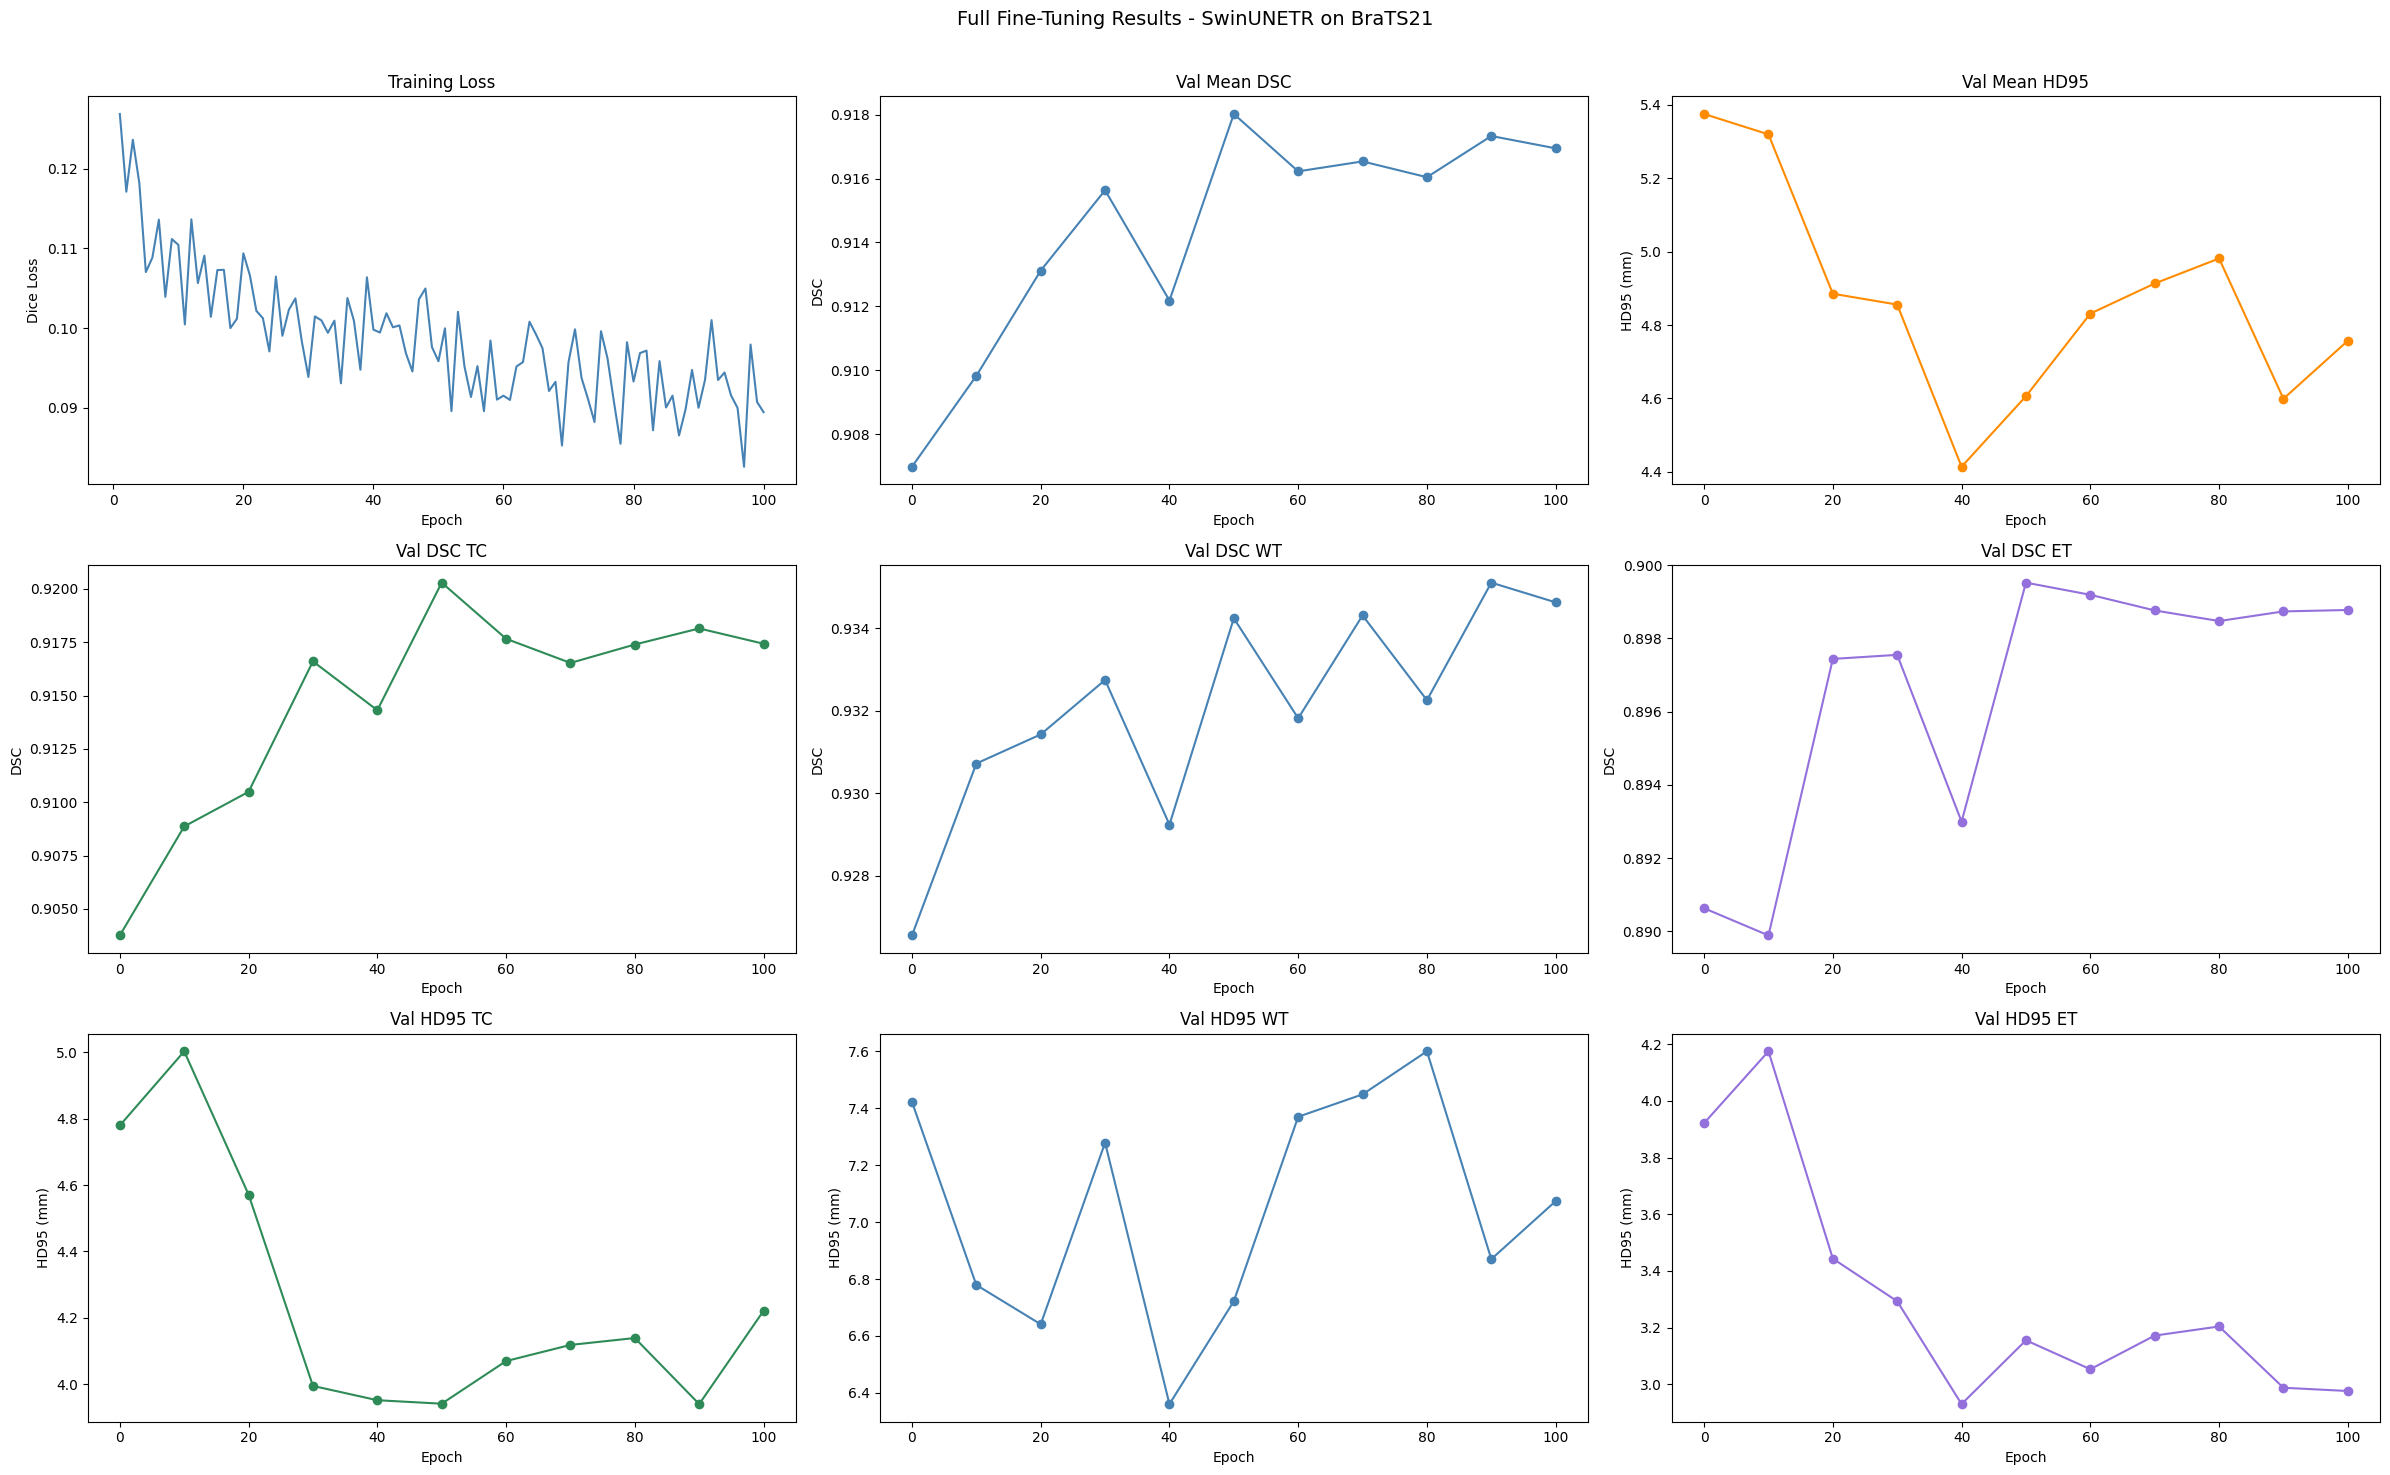

Plot saved - full_finetuning_curves.png.


In [18]:
# Use in-memory history if training just ran; otherwise load the saved results.
if "val_history" not in dir():
    with open(os.path.join(output_dir, "results_fine_tuning.json")) as f:
        results_ft = json.load(f)
    train_losses = results_ft["train_losses"]
    val_history  = results_ft["val_history"]

# Use the actual number of validations to build the x-axis (robust to whether an epoch-0 baseline was recorded).
val_epochs = build_val_epochs(len(val_history["val_dice_mean"]), val_every, max_epochs)

fig, axes = plt.subplots(3, 3, figsize=(24, 15))

# Row 0
axes[0, 0].plot(range(1, len(train_losses) + 1), train_losses, color="steelblue")
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Dice Loss")

axes[0, 1].plot(val_epochs, val_history["val_dice_mean"], marker="o", color="steelblue")
axes[0, 1].set_title("Val Mean DSC")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("DSC")

axes[0, 2].plot(val_epochs, val_history["val_hd95_mean"], marker="o", color="darkorange")
axes[0, 2].set_title("Val Mean HD95")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("HD95 (mm)")

# Row 1 - DSC per subregion
for ax, key, title, color in zip(
    [axes[1, 0], axes[1, 1], axes[1, 2]],
    ["val_dice_tc", "val_dice_wt", "val_dice_et"],
    ["Val DSC TC", "Val DSC WT", "Val DSC ET"],
    ["seagreen", "steelblue", "mediumpurple"]
):
    ax.plot(val_epochs, val_history[key], marker="o", color=color)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DSC")

# Row 2 - HD95 per subregion
for ax, key, title, color in zip(
    [axes[2, 0], axes[2, 1], axes[2, 2]],
    ["val_hd95_tc", "val_hd95_wt", "val_hd95_et"],
    ["Val HD95 TC", "Val HD95 WT", "Val HD95 ET"],
    ["seagreen", "steelblue", "mediumpurple"]
):
    ax.plot(val_epochs, val_history[key], marker="o", color=color)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("HD95 (mm)")

plt.suptitle("Full Fine-Tuning Results - SwinUNETR on BraTS21", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plot_path = os.path.join(output_dir, "full_finetuning_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved - full_finetuning_curves.png.")

## 14. Summary statistics table

Compute and display six summary metrics from the validation history to characterise model performance and convergence. These cover both DSC and HD95 across three reporting strategies: best achieved, final epoch and mean across all validation epochs.

In [41]:
val_dice_history  = val_history["val_dice_mean"][1:]   
val_hd95_history  = val_history["val_hd95_mean"][1:]

summary = {
    # DSC
    "Best DSC": max(val_dice_history),
    "Final epoch DSC": val_dice_history[-1],
    "Mean all epochs DSC": numpy.mean(val_dice_history),

    # HD95
    "Best HD95 (mm)": min(val_hd95_history),
    "Final epoch HD95 (mm)": val_hd95_history[-1],
    "Mean all epochs HD95": numpy.mean(val_hd95_history),
}

# Per-subregion at best epoch
be = int(best_metrics["best_epoch"])
assert abs(max(val_dice_history) - best_metrics["dice_mean"]) < 1e-6, "Summary 'Best DSC' and best_metrics disagree - different best-epoch definitions"

print("-" * 70)
print("SUMMARY - FULL FINE-TUNING RESULTS")
print("-" * 70)
print(f"\n{'Metric':<30} {'Value':>10}")
print("-" * 42)
for k, v in summary.items():
    print(f"{k:<30} {v:>10.4f}")

print(f"\n{'Best epoch':30} {be:>10}")

print("\n" + "-" * 70)
print("PER-SUBREGION METRICS AT BEST EPOCH")
print("-" * 70)
print(f"\n{'Metric':<20} {'TC':>10} {'WT':>10} {'ET':>10} {'Mean':>10}")
print("-" * 70)
print(f"{'DSC':<20} {best_metrics['dice_tc']:>10.4f} {best_metrics['dice_wt']:>10.4f} {best_metrics['dice_et']:>10.4f} {best_metrics['dice_mean']:>10.4f}")
print(f"{'HD95 (mm)':<20} {best_metrics['hd95_tc']:>10.2f} {best_metrics['hd95_wt']:>10.2f} {best_metrics['hd95_et']:>10.2f} {best_metrics['hd95_mean']:>10.2f}")

print("\n" + "-" * 70)
print("PRETRAINED BASELINE (epoch 0 - before fine-tuning)")
print("-" * 70)
print(f"DSC  → TC: {val_history['val_dice_tc'][0]:.4f} | WT: {val_history['val_dice_wt'][0]:.4f} | ET: {val_history['val_dice_et'][0]:.4f} | Mean: {val_history['val_dice_mean'][0]:.4f}")
print(f"HD95 → TC: {val_history['val_hd95_tc'][0]:.2f}  | WT: {val_history['val_hd95_wt'][0]:.2f}  | ET: {val_history['val_hd95_et'][0]:.2f}  | Mean: {val_history['val_hd95_mean'][0]:.2f}")

print("\n" + "-" * 110)
print("COMPARISON TABLE - PRETRAINED BASELINE vs FINE-TUNED")
print("-" * 110)
print(f"\n{'Model':<25} {'TC DSC':>8} {'WT DSC':>8} {'ET DSC':>8} {'Mean':>8} {'TC HD95':>9} {'WT HD95':>9} {'ET HD95':>9} {'Mean':>8}")
print("-" * 110)
print(f"{'Pretrained baseline':<25} "
      f"{val_history['val_dice_tc'][0]:>8.4f} "
      f"{val_history['val_dice_wt'][0]:>8.4f} "
      f"{val_history['val_dice_et'][0]:>8.4f} "
      f"{val_history['val_dice_mean'][0]:>8.4f} "
      f"{val_history['val_hd95_tc'][0]:>9.2f} "
      f"{val_history['val_hd95_wt'][0]:>9.2f} "
      f"{val_history['val_hd95_et'][0]:>9.2f} "
      f"{val_history['val_hd95_mean'][0]:>8.2f}")
print(f"{'Fine-tuned (Exp2)':<25} "
      f"{best_metrics['dice_tc']:>8.4f} "
      f"{best_metrics['dice_wt']:>8.4f} "
      f"{best_metrics['dice_et']:>8.4f} "
      f"{best_metrics['dice_mean']:>8.4f} "
      f"{best_metrics['hd95_tc']:>9.2f} "
      f"{best_metrics['hd95_wt']:>9.2f} "
      f"{best_metrics['hd95_et']:>9.2f} "
      f"{best_metrics['hd95_mean']:>8.2f}")

----------------------------------------------------------------------
SUMMARY - FULL FINE-TUNING RESULTS
----------------------------------------------------------------------

Metric                              Value
------------------------------------------
Best DSC                           0.9180
Final epoch DSC                    0.9169
Mean all epochs DSC                0.9152
Best HD95 (mm)                     4.4142
Final epoch HD95 (mm)              4.7572
Mean all epochs HD95               4.8162

Best epoch                             50

----------------------------------------------------------------------
PER-SUBREGION METRICS AT BEST EPOCH
----------------------------------------------------------------------

Metric                       TC         WT         ET       Mean
----------------------------------------------------------------------
DSC                      0.9203     0.9342     0.8995     0.9180
HD95 (mm)                  3.94       6.72       3.16       4

# Inference - Segmentation Mask Generation

Load the best fine-tuned checkpoint and run inference on the held-out validation set (fold val_fold). Each prediction is saved as a NIfTI mask for downstream feature extraction.

## 1. Define inference functions

Define `save_predictions` to run inference and save each predicted mask as a NIfTI file.

In [ ]:
@torch.no_grad()
def save_predictions(model, loader, files, device, masks_dir, roi_size=roi_size, overlap=overlap):
    model.eval()
    for i, batch in enumerate(loader):
        out  = sliding_window_inference(batch["image"].to(device), roi_size, 1, model, overlap=overlap)
        pred = (torch.sigmoid(out)[0] > 0.5)   # [3, H, W, D], order 0=TC, 1=WT, 2=ET
        tc, wt, et = pred[0], pred[1], pred[2]
        lab = torch.zeros(pred.shape[1:], dtype=torch.uint8, device=pred.device)
        lab[wt] = 2   # edema base (WT minus TC)
        lab[tc] = 1   # necrotic core overwrites
        lab[et] = 4   # enhancing tumor overwrites
        ref  = nibabel.load(files[i]["image"][0])
        case = os.path.basename(os.path.dirname(files[i]["label"]))
        nibabel.save(nibabel.Nifti1Image(lab.cpu().numpy(), ref.affine), os.path.join(masks_dir, f"pred_{case}.nii.gz"))
    print(f"Masks saved to: {masks_dir}")

print("Inference function defined (save_predictions).")
print(f"Finetuned model exists: {os.path.exists(finetuned_path)}")

## 2. Load fine-tuned model and save predicted masks

Load the best fine-tuned checkpoint and run `save_predictions` over the full validation set. Each mask is written as a NIfTI file preserving the original spatial metadata (affine), so it stays voxel-aligned with the source MRI. These masks are the input to the feature-extraction pipeline.

In [ ]:
ft_model = load_model(finetuned_path, device)
save_predictions(ft_model, val_loader, val_files, device, masks_dir, roi_size, overlap)
del ft_model
torch.cuda.empty_cache()

## 3. Verify a predicted mask

Load the first saved mask and confirm that its shape, dimensionality, and label values match the BraTS native format, using a 240 × 240 × 155 grid with labels {0, 1, 2, 4}, consistent with the ground truth masks.

In [ ]:
nii = nibabel.load(os.path.join(masks_dir, sorted(os.listdir(masks_dir))[0]))
arr = nii.get_fdata()
print("Shape:", arr.shape)
print("Ndim:", arr.ndim)
print("Unique values:", numpy.unique(arr)[:12])

## 4. Visual sanity check - Ground truth vs predicted mask

For the first validation patient, display the T1ce image alongside the ground truth and predicted segmentation masks on the axial slice with the most enhancing tumor voxels, providing a qualitative verification of segmentation quality.

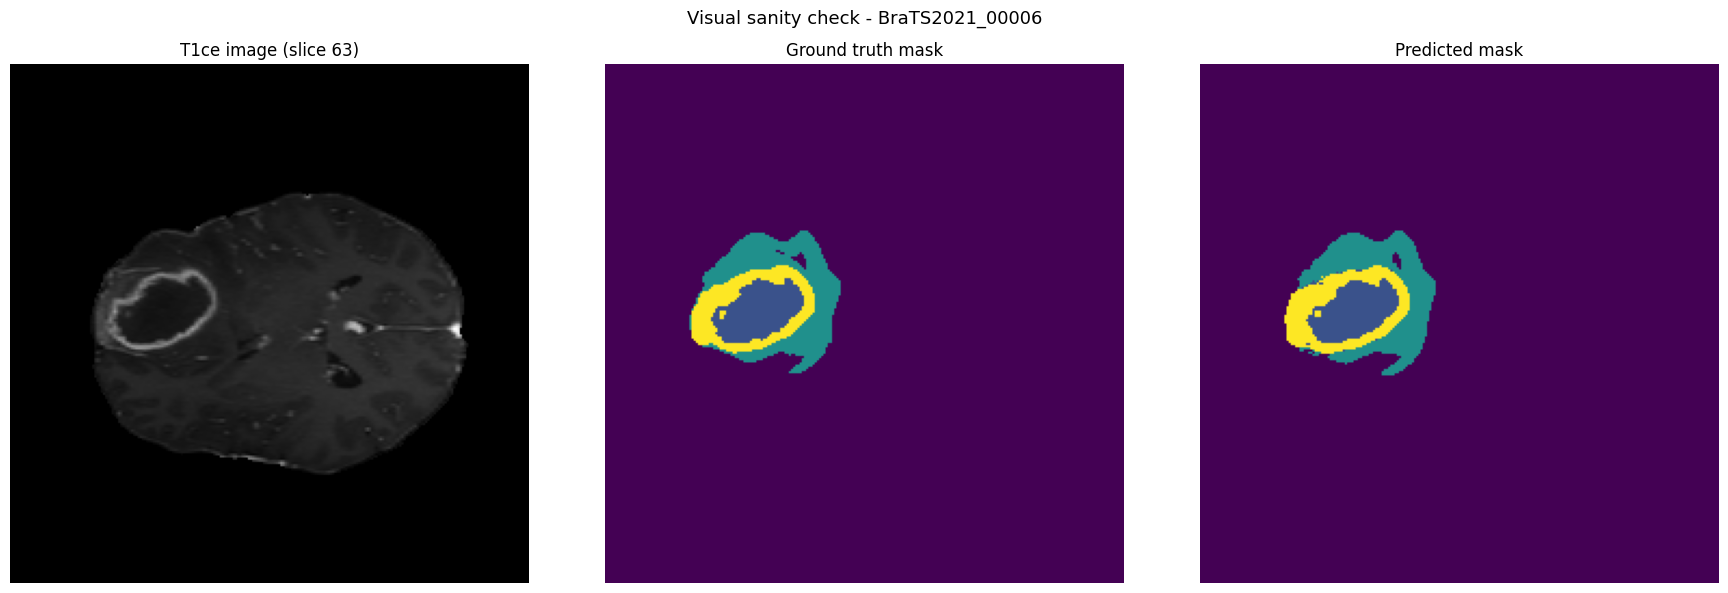

In [14]:
# Visual sanity check on a validation case, with all paths derived from val_files.
saved_masks = sorted(os.listdir(masks_dir))

# map predicted-mask patient id -> its val_files entry (same key save_predictions used)
val_by_pid = {os.path.basename(os.path.dirname(f["label"])): f for f in val_files}

pid = saved_masks[1].replace("pred_", "").replace(".nii.gz", "")
sample = val_by_pid[pid]

img = nibabel.load(sample["image"][1]).get_fdata()   # channel 1 = T1ce
gt = nibabel.load(sample["label"]).get_fdata()
pred = nibabel.load(os.path.join(masks_dir, f"pred_{pid}.nii.gz")).get_fdata()

best_slice = int(numpy.argmax((gt == 4).sum(axis=(0, 1))))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img[:, :, best_slice], cmap="gray", origin="lower")
axes[0].set_title(f"T1ce image (slice {best_slice})")
axes[0].axis("off")
axes[1].imshow(gt[:, :, best_slice], cmap="viridis", origin="lower")
axes[1].set_title("Ground truth mask")
axes[1].axis("off")
axes[2].imshow(pred[:, :, best_slice], cmap="viridis", origin="lower")
axes[2].set_title("Predicted mask")
axes[2].axis("off")

plt.suptitle(f"Visual sanity check - {pid}", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(output_dir, f"visual_check_{pid}.png"), dpi=150, bbox_inches="tight")
plt.show()

## Appendix - Exploratory checks

Non-essential exploratory inspections.

In [ ]:
# Inspect JSON structure to understand how training/validation patients are organized.
print(f"Type: {type(splits)}")
print(f"Keys or length: {len(splits) if isinstance(splits, list) else splits.keys()}")
print(f"\nFirst entry preview:")
print(json.dumps(splits[0] if isinstance(splits, list) else list(splits.values())[0], indent=2)[:500])

print(splits["training"][0]["image"][0])  # channel 0
print(splits["training"][0]["image"][1])  # channel 1
print(splits["training"][0]["image"][2])  # channel 2
print(splits["training"][0]["image"][3])  # channel 3
print(splits["training"][0]["label"]) 

## End of notebook

All experiments completed. Results are saved and can be used for further analysis or reporting.